# Enhancing Your Features with AI

##  Learning Outcomes

After this video, you'll be able to:

<ul>
    <li>Create AI-suggested features using Python</li>
    <li>Evaluate feature effectiveness</li>
    <li>Combine manual and AI-assisted approaches</li>
    <li>Implement features efficiently within AWS free tier limits</li>
</ul>

## Setup and Data Loading

In [1]:
import pandas as pd  
import numpy as np
from sklearn.preprocessing import StandardScaler  
from sklearn.feature_selection import mutual_info_classif  
import matplotlib.pyplot as plt  

df = pd.read_csv('insightlysoft_dataset.csv')
print("Initial features:", df.columns.tolist())

Initial features: ['account_id', 'monthly_login_freq', 'num_support_tickets', 'contract_length_months', 'avg_product_usage_hours', 'num_users', 'nps_score', 'has_admin_activity', 'last_activity_days_ago', 'avg_session_length', 'feature_adoption_score', 'customer_satisfaction_score', 'city', 'gender', 'churned', 'is_heavy_user']


## Basic Feature Creation

In [2]:
df['usage_per_user'] = df['avg_product_usage_hours'] / df['num_users']

In [3]:
df['tickets_per_user'] = df['num_support_tickets'] / df['num_users']

In [4]:
df['engagement_score'] = df['monthly_login_freq'] * df['avg_session_length']

In [5]:
df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned,is_heavy_user,usage_per_user,tickets_per_user,engagement_score
0,A0001,21,5.0,6,28.16,58,6.390714,0,5,1.51,89.98,8.42,Chicago,Female,0,1,0.485517,0.086207,31.71
1,A0002,13,5.0,6,18.70,33,0.792736,1,20,1.33,11.82,1.33,New York,Female,1,0,0.566667,0.151515,17.29
2,A0003,23,5.0,6,32.73,61,5.267689,0,2,0.48,31.07,6.60,Austin,Female,0,1,0.536557,0.081967,11.04
3,A0004,25,5.0,6,9.25,4,5.548030,0,34,2.04,77.84,5.75,Chicago,Male,1,1,2.312500,1.250000,51.00
4,A0005,16,18.0,24,29.08,99,-0.017153,0,4,1.92,54.32,0.31,Austin,Female,0,1,0.293737,0.181818,30.72


## AI-Assisted Feature Generation

In [6]:
def ai_feature_generator(df):
    """Simulate AI-suggested features"""
    new_features = {}
    
    # Complex engagement metric
    new_features['weighted_engagement'] = (
        df['monthly_login_freq'] * 
        df['feature_adoption_score'] / 
        (df['last_activity_days_ago'] + 1)
    )

    # Customer health score
    new_features['health_score'] = (
        df['customer_satisfaction_score'] * 0.4 +
        df['nps_score'].clip(-100, 100) / 100 * 0.3 +
        df['feature_adoption_score'] / 100 * 0.3
    )

    # Add new features to the original DataFrame
    for key, value in new_features.items():
        df[key] = value

    return df

df = ai_feature_generator(df)
df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,...,customer_satisfaction_score,city,gender,churned,is_heavy_user,usage_per_user,tickets_per_user,engagement_score,weighted_engagement,health_score
0,A0001,21,5.0,6,28.16,58,6.390714,0,5,1.51,...,8.42,Chicago,Female,0,1,0.485517,0.086207,31.71,314.930000,3.657112
1,A0002,13,5.0,6,18.70,33,0.792736,1,20,1.33,...,1.33,New York,Female,1,0,0.566667,0.151515,17.29,7.317143,0.569838
2,A0003,23,5.0,6,32.73,61,5.267689,0,2,0.48,...,6.60,Austin,Female,0,1,0.536557,0.081967,11.04,238.203333,2.749013
3,A0004,25,5.0,6,9.25,4,5.548030,0,34,2.04,...,5.75,Chicago,Male,1,1,2.312500,1.250000,51.00,55.600000,2.550164
4,A0005,16,18.0,24,29.08,99,-0.017153,0,4,1.92,...,0.31,Austin,Female,0,1,0.293737,0.181818,30.72,173.824000,0.286909


## Feature Evaluation

In [7]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
X = df[numeric_features].drop('churned', axis=1)

mi_scores = mutual_info_classif(X, df['churned'])

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': mi_scores
}).sort_values(by='importance', ascending=False)

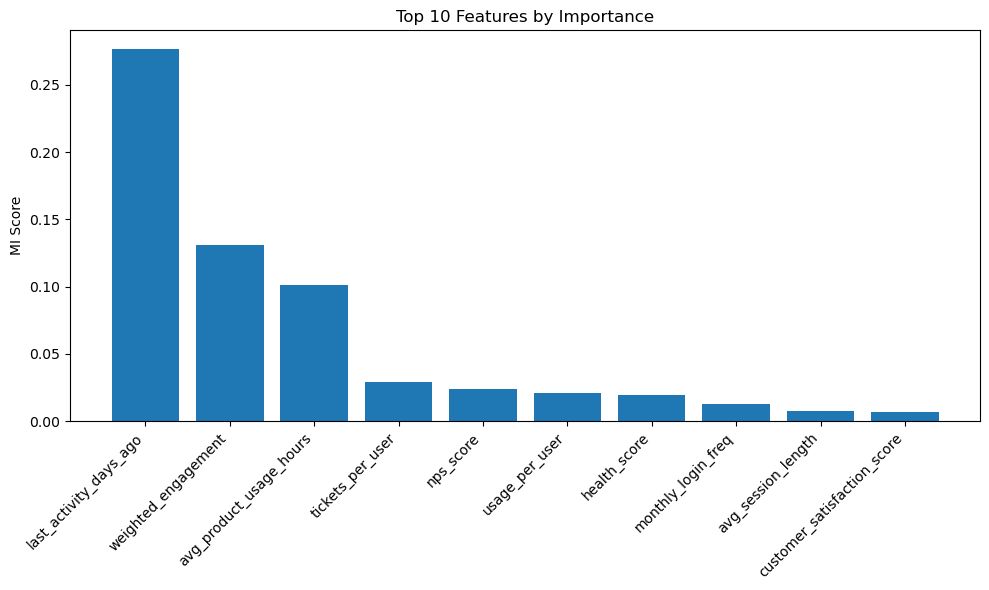

In [8]:
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'][:10], 
        feature_importance['importance'][:10])
plt.xticks(rotation=45, ha='right')  # Rotate and align labels
plt.title('Top 10 Features by Importance')
plt.ylabel('MI Score')
plt.tight_layout()  
plt.show()

## Implementation Best Practice

- Validate against business logic

- Monitor memory usage

- Document feature creation

- Test feature stability


## Recap


In this video, we covered:

- Creating manual baseline features 

- Implementing AI-suggested features 

- Evaluating feature importance 

- Reviewing best practices

